FrozenLake-v1 8x8 model
states: 64, actions: 4
Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action


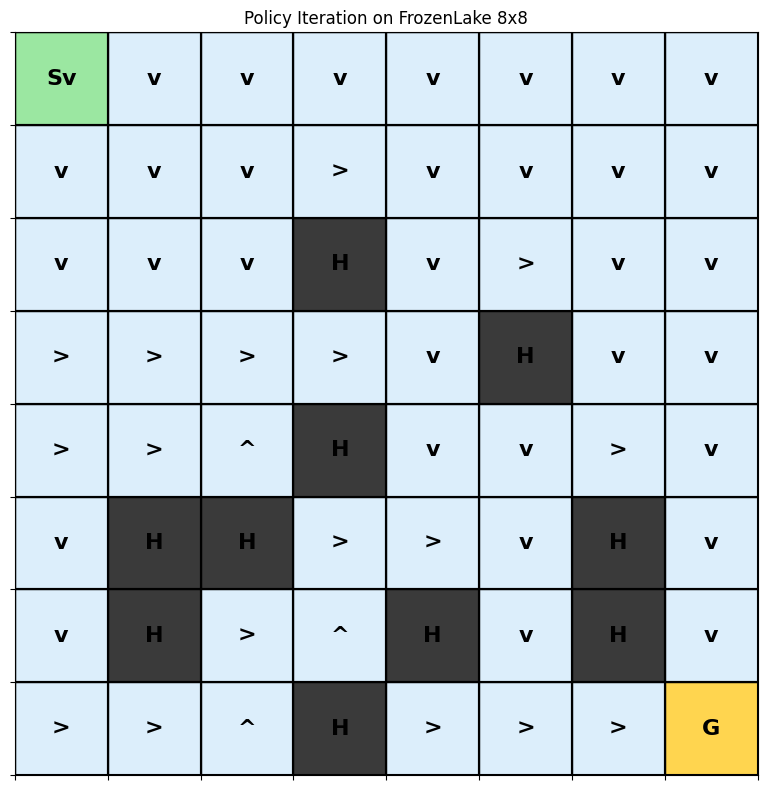

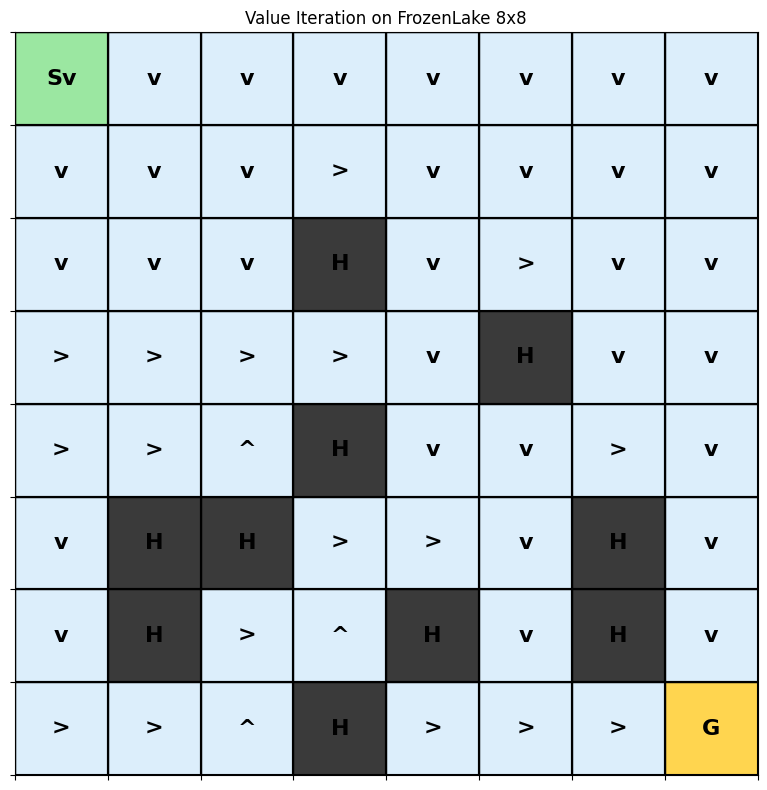

In [5]:
from __future__ import annotations

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

def build_env(map_name: str = "8x8", slippery: bool = True, desc=None):
	return gym.make(
		"FrozenLake-v1",
		map_name=map_name,
		is_slippery=slippery,
		render_mode="ansi",
		reward_schedule=(100,-50,-1),
		desc=desc
	)

def extract_model(env: gym.Env):
	n_states = env.observation_space.n
	n_actions = env.action_space.n
	transition = np.zeros((n_states, n_actions, n_states), dtype=float)
	reward = np.zeros((n_states, n_actions, n_states), dtype=float)

	for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
				transition[state, action, next_state] += prob # Probability of reaching s', given that action a is done on state s.
				reward[state, action, next_state] = r

	expected_reward = np.sum(transition * reward, axis=2) # Expected reward if action a is taken on state s.
	return transition, reward, expected_reward

def q_values(transition, expected_reward, values, gamma):
	future = np.einsum("sat,t->sa", transition, values) # Summation P(s'|s,a)*V(s') over all s'.
	return expected_reward + gamma * future

def policy_evaluation_matrix(transition, expected_reward, policy, gamma=0.99):
	n_states = transition.shape[0]
	rows = np.arange(n_states)
	policy_transition = transition[rows, policy]
	policy_reward = expected_reward[rows, policy]
	system = np.eye(n_states) - gamma * policy_transition
	values = np.linalg.solve(system, policy_reward)
	return values

def value_iteration(transition, expected_reward, gamma=0.99, max_iterations=1000):
	n_states = transition.shape[0]
	values = np.zeros(n_states)

	for iteration in range(max_iterations):
		q = q_values(transition, expected_reward, values, gamma)
		new_values = np.max(q, axis=1)
		if np.array_equal(new_values, values):
			policy = np.argmax(q, axis=1)
			return values, policy, iteration+1

		values = new_values

	q_final = q_values(transition, expected_reward, values, gamma)
	policy = np.argmax(q_final, axis=1)
	return values, policy, max_iterations

def policy_iteration(transition, expected_reward, gamma=0.99, max_iterations=1000):
	n_states = transition.shape[0]
	policy = np.zeros(n_states, dtype=int)

	for iteration in range(max_iterations):
		values = policy_evaluation_matrix(transition, expected_reward, policy, gamma)
		q = q_values(transition, expected_reward, values, gamma)
		new_policy = np.argmax(q, axis=1)
		if np.array_equal(new_policy, policy):
			return values, policy, iteration + 1
		policy = new_policy

	values = policy_evaluation_matrix(transition, expected_reward, policy, gamma)
	return values, policy, max_iterations

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

def main():
	gamma = 0.99
	custom_map = [
		"SFFFFFFF",
		"FFFFFFFF",
		"FFFHFFFF",
		"FFFFFHFF",
		"FFFHFFFF",
		"FHHFFFHF",
		"FHFFHFHF",
		"FFFHFFFG"
	]
	env = build_env(map_name="8x8", slippery=False, desc=custom_map)
	transition, reward, expected_reward = extract_model(env)

	print("FrozenLake-v1 8x8 model")
	print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
	print("Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action")

	_, pi_policy, _ = policy_iteration(transition, expected_reward, gamma=gamma)

	plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")

	_, vi_policy, _ = value_iteration(transition, expected_reward, gamma=gamma)

	plot_policy_on_frozen_lake(env, vi_policy, title="Value Iteration on FrozenLake 8x8")

if __name__ == "__main__":
	main()
